In [6]:
import pandas as pd
import gseapy as gp
from pathlib import Path
import matplotlib.pyplot as plt

#paths:
results_dir = Path.home() / "emt_network" / "results"
figures_dir = Path.home() / "emt_network" / "figures"

In [7]:
# Loading corehubs:-
file_path = results_dir / "core_top_hubs_selected.tsv"


core_hubs = pd.read_csv(file_path, sep="\t")


print("Total core genes:", len(core_hubs))
core_hubs.head()

Total core genes: 20


,node,out_degree,in_degree,total_degree
0,TRPC1,5,8,13
1,TRPC3,1,10,11
2,TRPC6,0,6,6
3,TRPV1,0,5,5
4,TRPC5,2,2,4


In [8]:
#Over representation analysis:
gene_list = core_hubs['node'].tolist()

print("Running pathway analysis...")
enr = gp.enrichr(gene_list=gene_list,
                 gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2023'],
                 organism='human',
                 outdir=None)


enr.results.head()

Running pathway analysis...


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Inflammatory mediator regulation of TRP channels,7/98,4.012180e-12,4.293032e-10,0,0,117.686391,3088.289355,TRPV4;ITPR1;ITPR3;CALM3;TRPV1;CALM1;CALM2
1,KEGG_2021_Human,cGMP-PKG signaling pathway,7/167,1.764323e-10,8.442417e-09,0,0,66.701923,1497.997382,TRPC6;ITPR1;ITPR3;CALM3;CALM1;CALM2;PRKG1
2,KEGG_2021_Human,Salivary secretion,6/93,3.156044e-10,8.442417e-09,0,0,97.995074,2143.792333,ITPR1;ITPR3;CALM3;CALM1;CALM2;PRKG1
3,KEGG_2021_Human,GnRH signaling pathway,6/93,3.156044e-10,8.442417e-09,0,0,97.995074,2143.792333,ITPR1;ITPR3;CALM3;CALM1;CALM2;EGFR
4,KEGG_2021_Human,Circadian entrainment,6/97,4.081665e-10,8.734763e-09,0,0,93.668760,2025.057320,ITPR1;ITPR3;CALM3;CALM1;CALM2;PRKG1


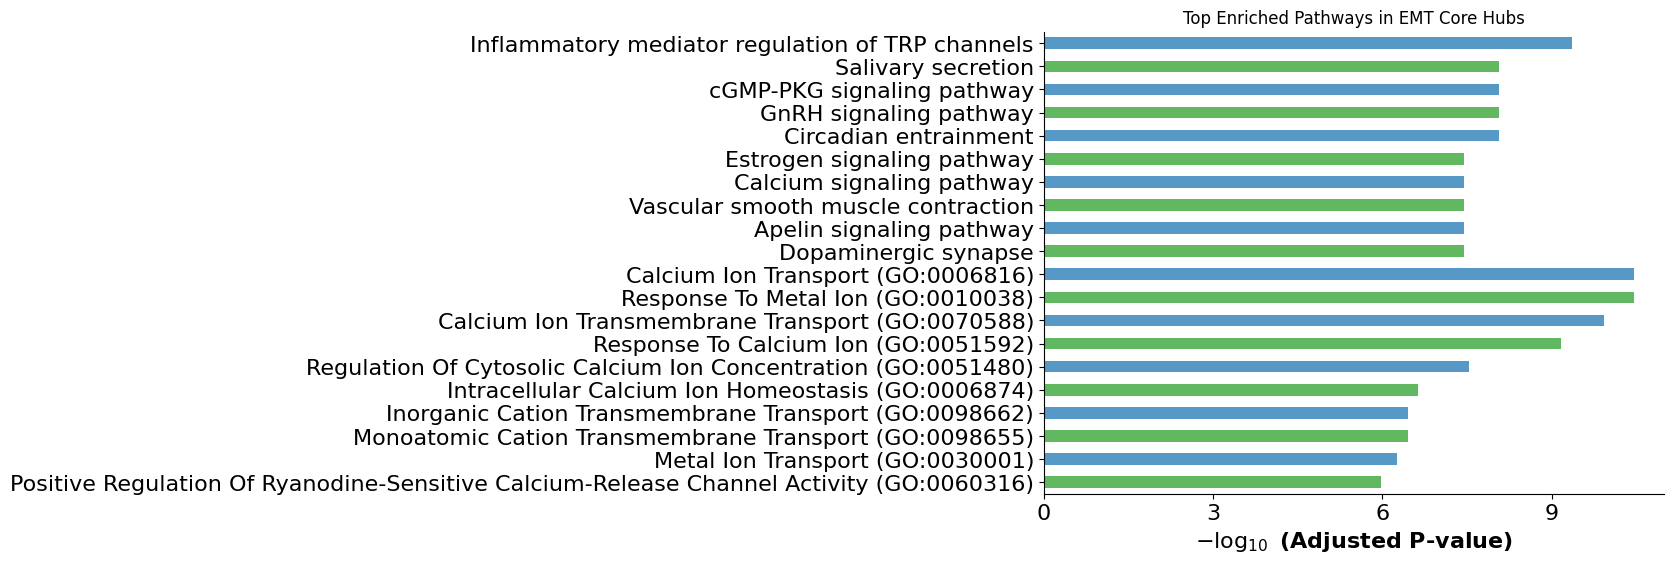

In [9]:
#Visual analysis:
from gseapy import barplot


ax = barplot(enr.results, 
             column="Adjusted P-value", 
             group='Gene_set', 
             size=10, 
             top_term=10, 
             figsize=(8, 6),
             color=['#2ca02c', '#1f77b4']) # Green and Blue

plt.title("Top Enriched Pathways in EMT Core Hubs")
plt.savefig(figures_dir / "pathway_enrichment_hubs.png", bbox_inches='tight')
plt.show()

In [10]:
#key EMT markers:


logfc_path = Path.home() / "emt_network" / "resources" / "signatures_generated" / "tcga_brca_M_vs_E_logFC.tsv"
tcga_logfc = pd.read_csv(logfc_path, sep="\t")


key_markers = ['CDH1', 'VIM', 'SNAI1', 'SNAI2', 'ZEB1', 'TWIST1']


validation = tcga_logfc[tcga_logfc.iloc[:, 0].isin(key_markers)]
print("Validation: Expression of Key Markers")
print(validation)

Validation: Expression of Key Markers
    Unnamed: 0  logFC_M_minus_E
58        CDH1         1.450512
65       SNAI2         1.409653
91         VIM         1.186116
101     TWIST1         1.119488
143       ZEB1         0.879719
165      SNAI1         0.757372
